# VC Prompt Version Comparison (46 GT Images)
Compare V0–V3 prompt versions on the 46 ground-truth calibration images.

| Version | Description |
|---------|-------------|
| V0 | Pure zero-shot: VC definition only, no dimensions, no anchors |
| V1 | Zero-shot with 7 dimension descriptions, no anchors |
| V2 | VC definition + 3 anchors (vc_score only), no dimensions |
| V3 | Full prompt: dimensions + calibration guidance + weighting + 3 anchors (full scores) |

**Note:** The 3 anchor images are excluded from evaluation, leaving **43 non-anchor images** for a fair comparison.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib
matplotlib.rcParams['figure.dpi'] = 120
matplotlib.rcParams['font.size'] = 10

In [22]:
# ── Load GT and all version scores ──────────────────────────────────
gt = pd.read_csv('gt_all_46.csv')

# Exclude the 3 anchor images (used as few-shot examples in V2/V3)
ANCHOR_IMAGES = {'VisC.503.6.png', 'InfoVisJ.619.17.png', 'InfoVisJ.1149.6(1).png'}
gt = gt[~gt['imageName'].isin(ANCHOR_IMAGES)].reset_index(drop=True)
print(f'GT images: {len(gt)} (excluded {len(ANCHOR_IMAGES)} anchors)')

VERSIONS = {
    'V0': '../vc_api_46gt_v0/vc_scores.csv',
    'V1': '../vc_api_46gt_v1/vc_scores.csv',
    'V2': '../vc_api_46gt_v2/vc_scores.csv',
    'V3': '../vc_api_46gt_v3/vc_scores.csv',
}

dfs = {}
for ver, path in VERSIONS.items():
    s = pd.read_csv(path)
    merged = gt.merge(s[['filename', 'vc_score']], left_on='imageName', right_on='filename', how='inner')
    merged = merged.rename(columns={'vc_score': f'pred_{ver}'})
    dfs[ver] = merged
    print(f'{ver}: {len(merged)} images matched')

# Build combined dataframe
df = gt.copy()
for ver in VERSIONS:
    df = df.merge(dfs[ver][['imageName', f'pred_{ver}']], on='imageName', how='inner')
print(f'\nCombined: {len(df)} images with all 4 versions')
df.head()

GT images: 43 (excluded 3 anchors)
V0: 43 images matched
V1: 43 images matched
V2: 43 images matched
V3: 43 images matched

Combined: 43 images with all 4 versions


,imageName,NormalizedVC,pred_V0,pred_V1,pred_V2,pred_V3
0,wsj135.png,0.35,0.38,0.36,0.38,0.33
1,SciVisJ.1025.11.png,0.36,0.45,0.46,0.42,0.38
2,visMost97.png,0.38,0.25,0.25,0.20,0.23
3,economist_daily_chart_165.png,0.43,0.52,0.42,0.52,0.42
4,whoO06_2.png,0.45,0.62,0.57,0.58,0.53


## 1. Performance Metrics

In [20]:
def compute_metrics(y_true, y_pred):
    r, p_r = stats.pearsonr(y_true, y_pred)
    rho, p_rho = stats.spearmanr(y_true, y_pred)
    return {
        'Pearson r': r,
        'Spearman \u03c1': rho,
        'R\u00b2': r**2,
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'Bias': np.mean(y_pred - y_true),
        'p (Pearson)': p_r,
    }

rows = []
for ver in VERSIONS:
    m = compute_metrics(df['NormalizedVC'].values, df[f'pred_{ver}'].values)
    m['Version'] = ver
    rows.append(m)

metrics = pd.DataFrame(rows).set_index('Version')
print(metrics.to_string(float_format='%.4f'))

         Pearson r  Spearman ρ     R²    MAE   RMSE    Bias  p (Pearson)
Version                                                                 
V0          0.8683      0.8663 0.7540 0.0805 0.0982  0.0088       0.0000
V1          0.8305      0.8155 0.6897 0.0856 0.1067 -0.0433       0.0000
V2          0.8681      0.8649 0.7536 0.0830 0.1033 -0.0119       0.0000
V3          0.9005      0.8960 0.8110 0.0756 0.0910 -0.0253       0.0000


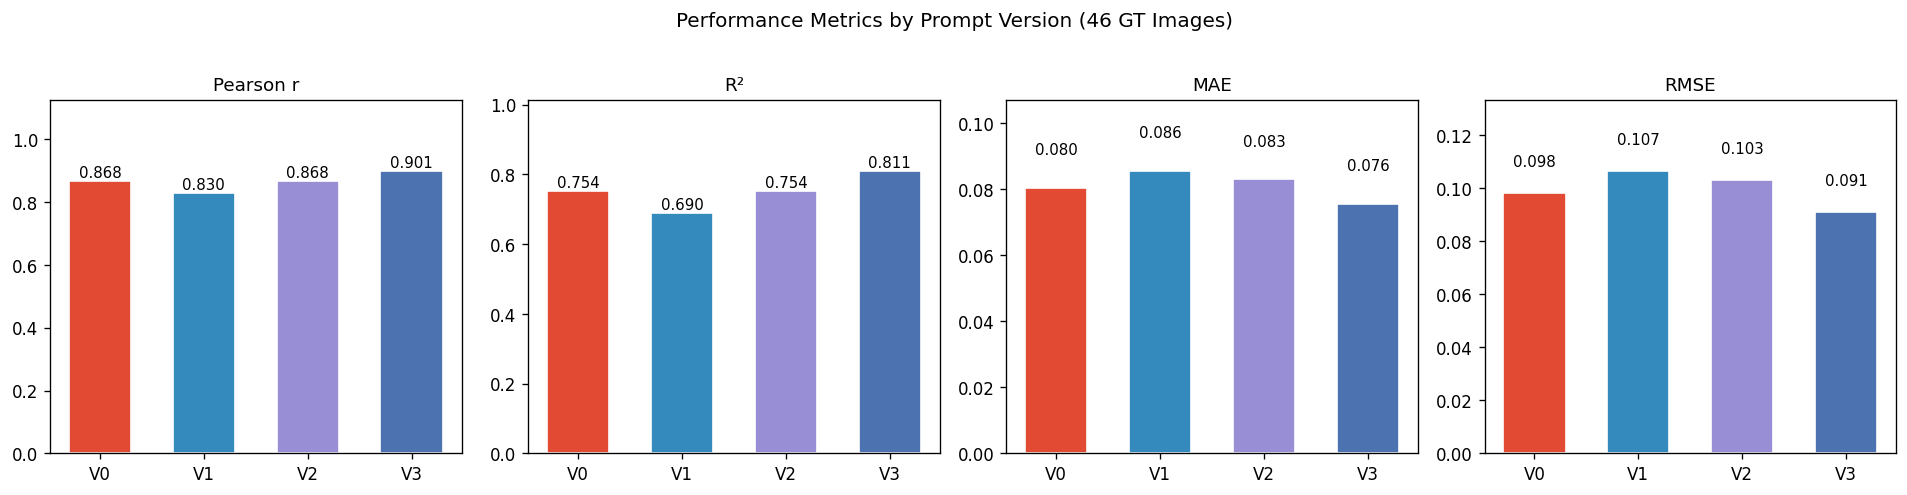

In [14]:
# ── Bar chart of key metrics across versions ───────────────────────
key_metrics = ['Pearson r', 'R\u00b2', 'MAE', 'RMSE']
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
colors = ['#E24A33', '#348ABD', '#988ED5', '#4C72B0']
versions = list(VERSIONS.keys())

for ax, metric in zip(axes, key_metrics):
    vals = [metrics.loc[v, metric] for v in versions]
    bars = ax.bar(versions, vals, color=colors, edgecolor='white', width=0.6)
    ax.set_title(metric, fontsize=11)
    ax.set_ylim(0, max(vals) * 1.25)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                f'{val:.3f}', ha='center', fontsize=9)

fig.suptitle('Performance Metrics by Prompt Version (46 GT Images)', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig('figures/version_metrics_bar.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Scatter Plots: Predicted vs Ground Truth

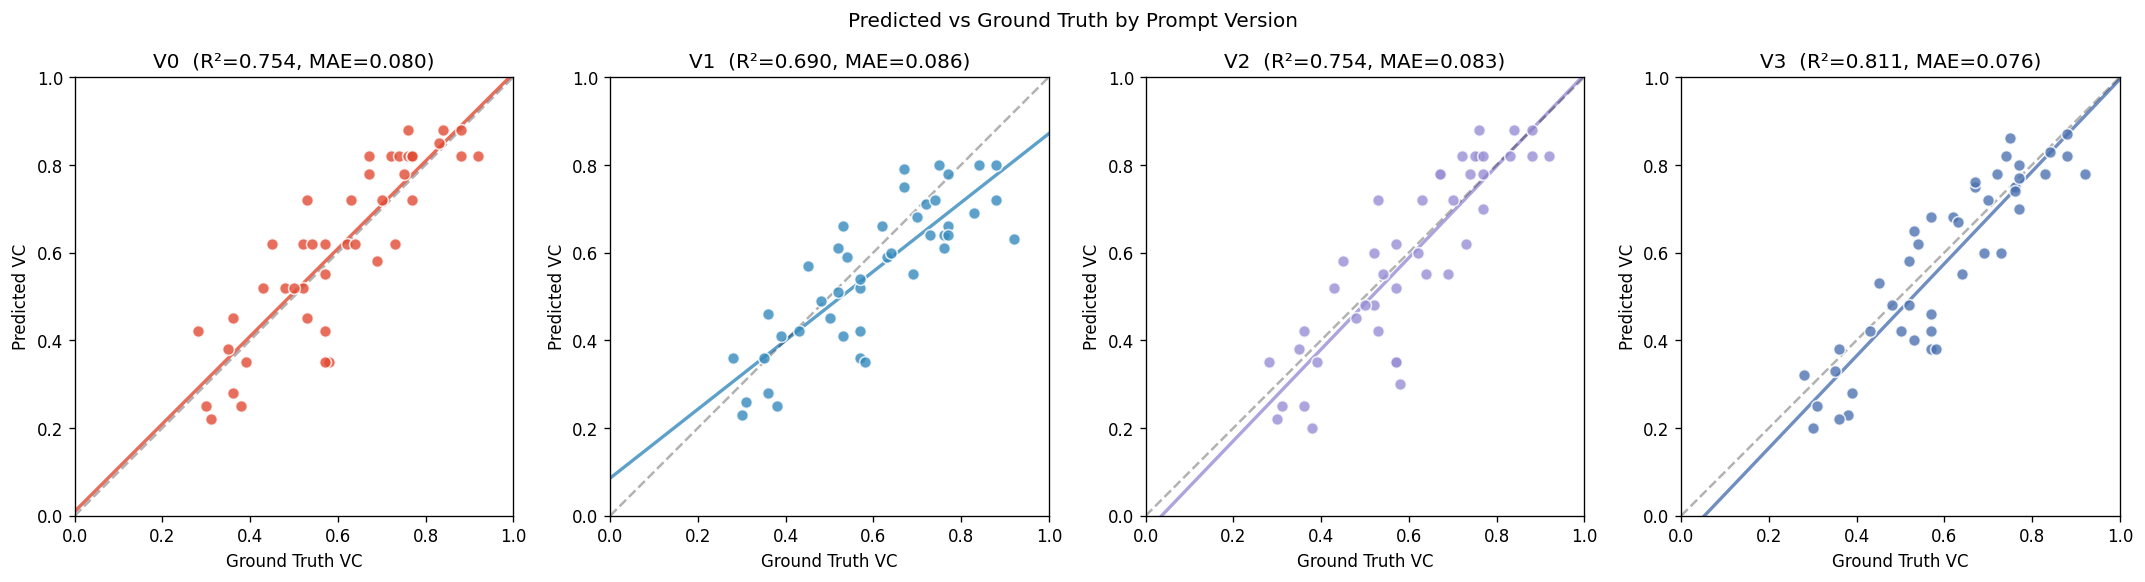

In [15]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4.5))

for ax, ver, color in zip(axes, versions, colors):
    y_true = df['NormalizedVC'].values
    y_pred = df[f'pred_{ver}'].values
    r2 = metrics.loc[ver, 'R\u00b2']
    mae = metrics.loc[ver, 'MAE']

    ax.scatter(y_true, y_pred, c=color, edgecolors='white', s=50, alpha=0.8, zorder=3)

    # Regression line
    slope, intercept, _, _, _ = stats.linregress(y_true, y_pred)
    x_fit = np.linspace(0, 1, 100)
    ax.plot(x_fit, slope * x_fit + intercept, c=color, linewidth=2, alpha=0.8)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3)

    ax.set_xlabel('Ground Truth VC')
    ax.set_ylabel('Predicted VC')
    ax.set_title(f'{ver}  (R\u00b2={r2:.3f}, MAE={mae:.3f})')
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.set_aspect('equal')

fig.suptitle('Predicted vs Ground Truth by Prompt Version', fontsize=12, y=1.02)
fig.tight_layout()
fig.savefig('figures/version_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Error Distribution

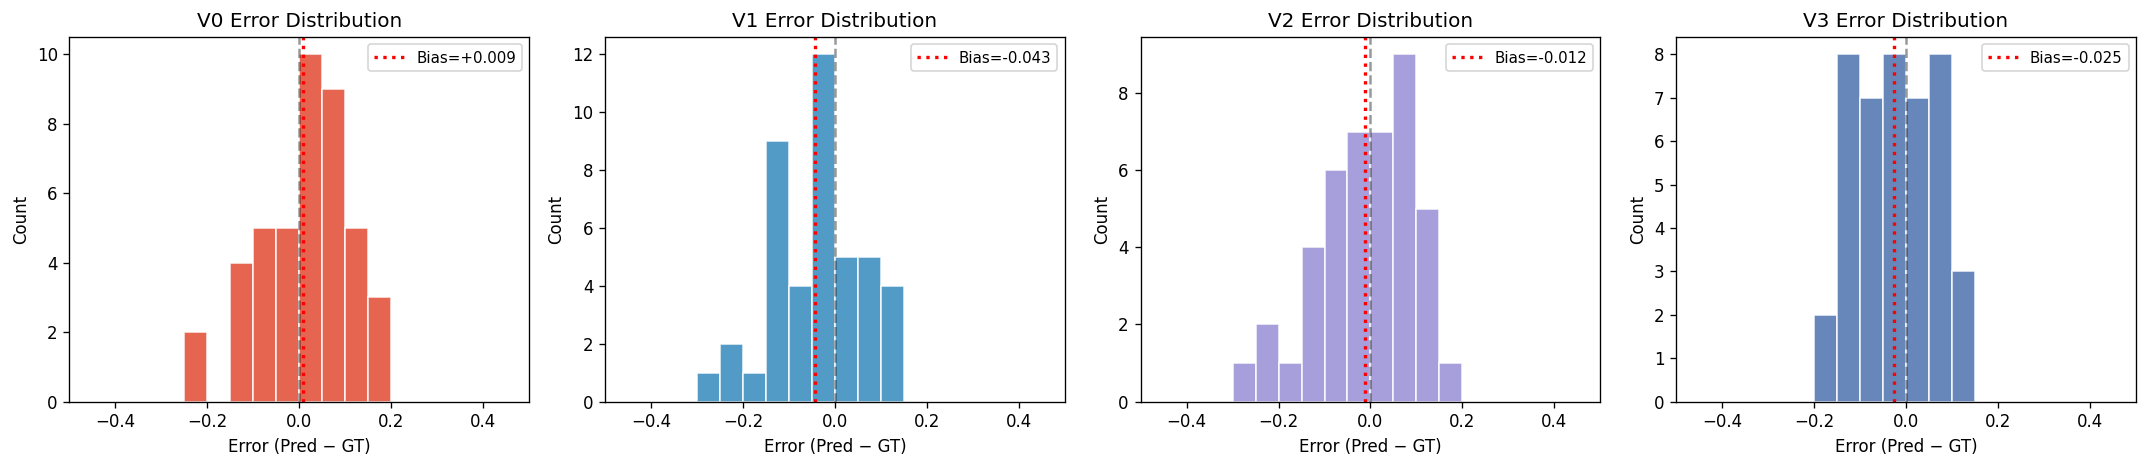

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
bins = np.arange(-0.5, 0.55, 0.05)

for ax, ver, color in zip(axes, versions, colors):
    errors = df[f'pred_{ver}'].values - df['NormalizedVC'].values
    bias = errors.mean()
    ax.hist(errors, bins=bins, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(0, color='black', linestyle='--', alpha=0.4)
    ax.axvline(bias, color='red', linestyle=':', linewidth=2, label=f'Bias={bias:+.3f}')
    ax.set_xlabel('Error (Pred \u2212 GT)')
    ax.set_ylabel('Count')
    ax.set_title(f'{ver} Error Distribution')
    ax.legend(fontsize=9)
    ax.set_xlim(-0.5, 0.5)

fig.tight_layout()
fig.savefig('figures/version_error_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Per-Image Comparison

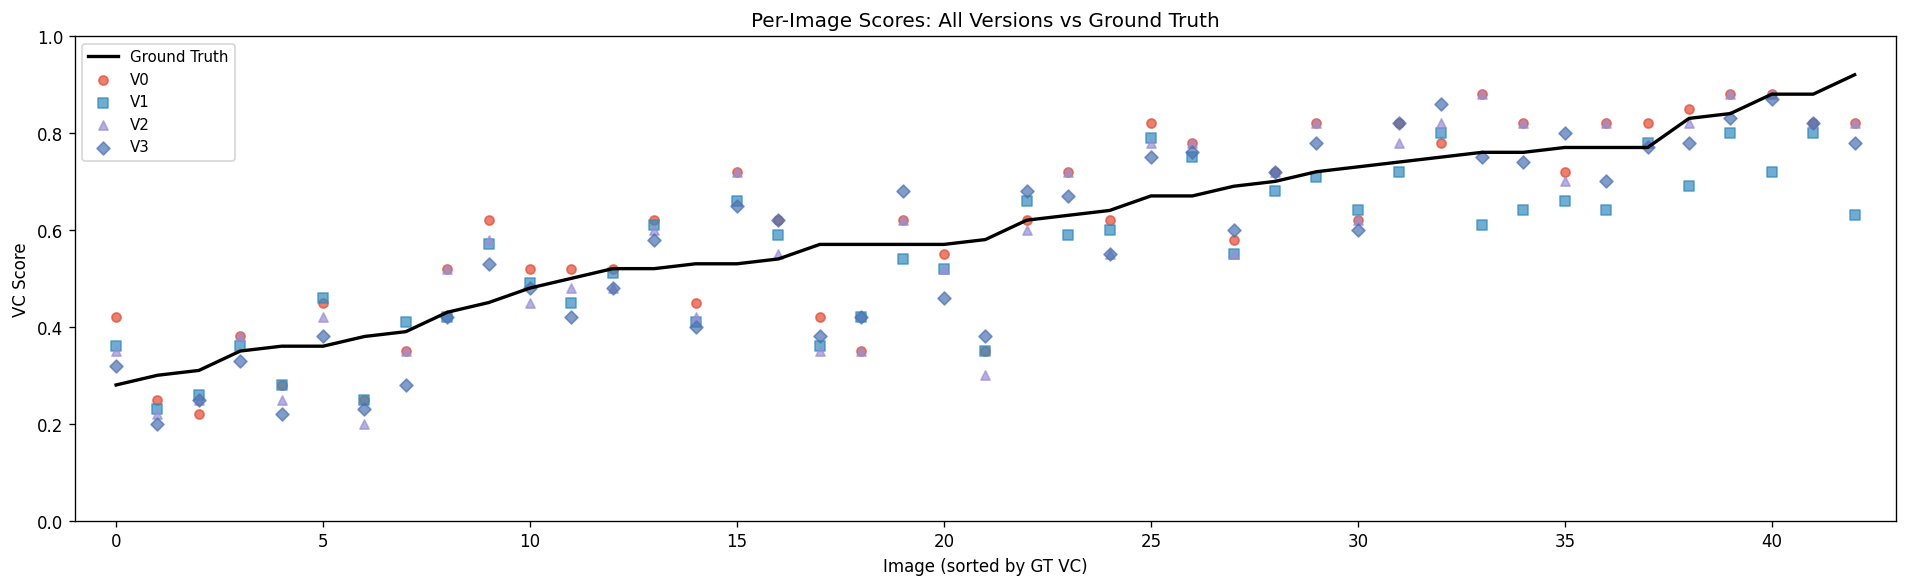

In [17]:
# Sort by GT score and plot all versions
df_sorted = df.sort_values('NormalizedVC').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(16, 5))
x = np.arange(len(df_sorted))

ax.plot(x, df_sorted['NormalizedVC'].values, 'k-', linewidth=2, label='Ground Truth', zorder=5)
for ver, color, marker in zip(versions, colors, ['o', 's', '^', 'D']):
    ax.scatter(x, df_sorted[f'pred_{ver}'].values, c=color, marker=marker,
               s=30, alpha=0.7, label=ver, zorder=3)

ax.set_xlabel('Image (sorted by GT VC)')
ax.set_ylabel('VC Score')
ax.set_title('Per-Image Scores: All Versions vs Ground Truth')
ax.legend(fontsize=9, loc='upper left')
ax.set_xlim(-1, len(df_sorted))
ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig('figures/version_per_image.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Score Distribution by Version

C:\Users\mling\AppData\Local\Temp\ipykernel_1512\3296763310.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)


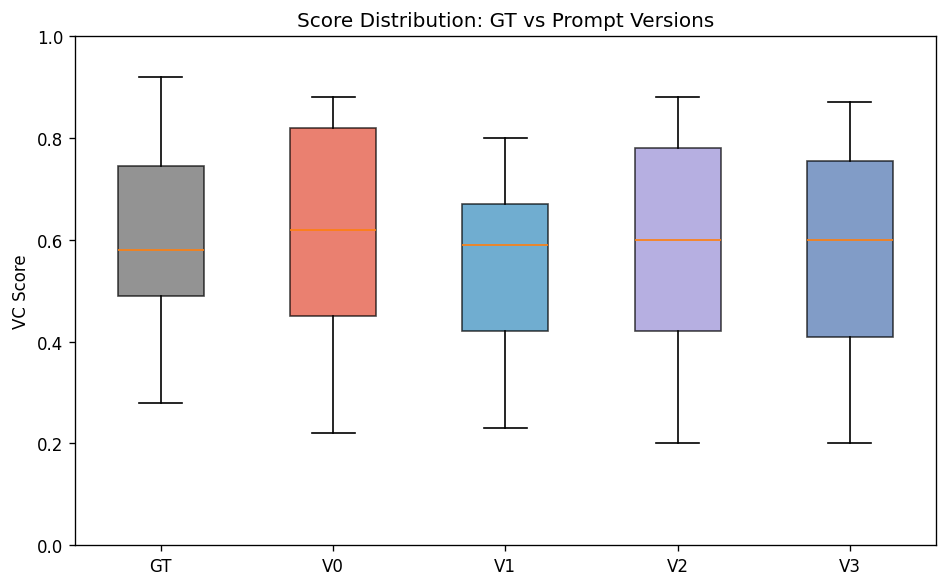

In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

data = [df['NormalizedVC'].values] + [df[f'pred_{v}'].values for v in versions]
labels = ['GT'] + versions
bp = ax.boxplot(data, labels=labels, patch_artist=True, widths=0.5)

box_colors = ['#666666'] + colors
for patch, c in zip(bp['boxes'], box_colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.7)

ax.set_ylabel('VC Score')
ax.set_title('Score Distribution: GT vs Prompt Versions')
ax.set_ylim(0, 1)

fig.tight_layout()
fig.savefig('figures/version_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Summary Table

In [21]:
# Summary with descriptive stats
summary_rows = []
for ver in versions:
    pred = df[f'pred_{ver}']
    m = metrics.loc[ver]
    summary_rows.append({
        'Version': ver,
        'Mean': pred.mean(),
        'Std': pred.std(),
        'Min': pred.min(),
        'Max': pred.max(),
        'Pearson r': m['Pearson r'],
        'R\u00b2': m['R\u00b2'],
        'MAE': m['MAE'],
        'Bias': m['Bias'],
    })

summary = pd.DataFrame(summary_rows).set_index('Version')
print('GT:  mean={:.3f}, std={:.3f}, range=[{:.2f}, {:.2f}]'.format(
    df['NormalizedVC'].mean(), df['NormalizedVC'].std(),
    df['NormalizedVC'].min(), df['NormalizedVC'].max()))
print()
print(summary.to_string(float_format='%.3f'))

GT:  mean=0.601, std=0.174, range=[0.28, 0.92]

         Mean   Std   Min   Max  Pearson r    R²   MAE   Bias
Version                                                      
V0      0.610 0.200 0.220 0.880      0.868 0.754 0.080  0.009
V1      0.557 0.164 0.230 0.800      0.830 0.690 0.086 -0.043
V2      0.589 0.209 0.200 0.880      0.868 0.754 0.083 -0.012
V3      0.575 0.202 0.200 0.870      0.901 0.811 0.076 -0.025
